<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0" width=150px> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Epidemiology 304</h1>
<h1>Demographics</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
from collections import Counter
from pprint import pprint

import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.lines import Line2D


from ipywidgets import interact

import epidemik
from epidemik import EpiModel

import tqdm as tq
from tqdm.notebook import tqdm

import watermark

%load_ext watermark
%matplotlib inline

We start by printing out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.12.3

Compiler    : Clang 14.0.6 
OS          : Darwin
Release     : 24.3.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 6d9f1a6eb4084a40d0e306ad0ba8a2eaa55e5c85

epidemik  : 0.1.3.3
numpy     : 1.26.4
watermark : 2.4.3
matplotlib: 3.8.0
pandas    : 2.2.3
tqdm      : 4.66.4



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Basic SIR model

We load the usual SIR model from the model library

In [4]:
SIR = EpiModel.download_model('SIR.yaml')
print(SIR)

# Epidemic Model with 3 compartments and 2 transitions:
Name: SIR

Parameters:
  beta : 0.2
  mu : 0.1


Transitions:
  - I -> R mu
  - S + I = I beta

# R0=2.00


And update the infection rate

In [5]:
SIR.params['beta'] = 0.3

In [6]:
print(SIR)

# Epidemic Model with 3 compartments and 2 transitions:
Name: SIR

Parameters:
  beta : 0.3
  mu : 0.1


Transitions:
  - I -> R mu
  - S + I = I beta

# R0=3.00


We set the inital conditions

In [7]:
N = 10_000
I0 = 1
R0 = 0
S0 = N - I0 - R0
tmax = 160

And we integrate it

In [8]:
SIR.integrate(tmax, S=S0, I=I0, R=R0)

And visualize the results

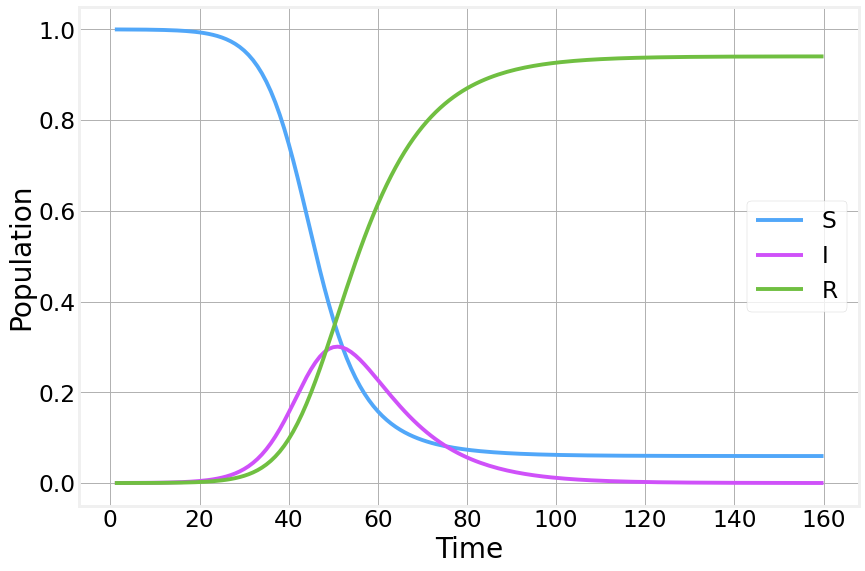

In [9]:
fig, ax = plt.subplots(1)
(SIR.S/N).plot(ax=ax) 
(SIR.I/N).plot(ax=ax)
(SIR.R/N).plot(ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.legend()

# Demographics

First we explore the demographics functionality with a simple model

In [10]:
simple = EpiModel()
simple.add_birth_rate('S', birth=0.1)

In [11]:
simple.integrate(tmax, S=N)

Text(0, 0.5, 'Population')

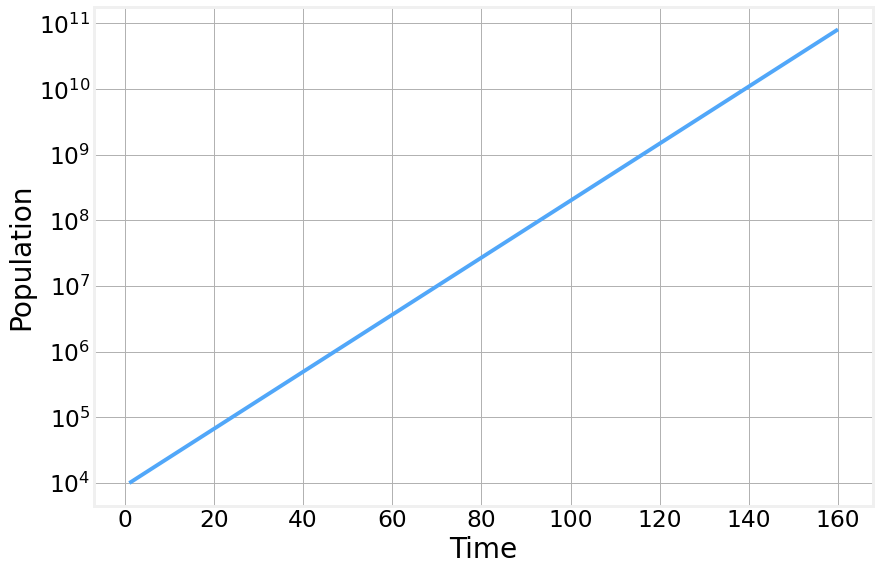

In [12]:
fig, ax = plt.subplots(1)
ax.set_yscale('log')
simple.S.plot(ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Population')


In [13]:
simple.add_death_rate('S', death=0.1)

In [14]:
simple.integrate(tmax, S=N)

Text(0, 0.5, 'Population')

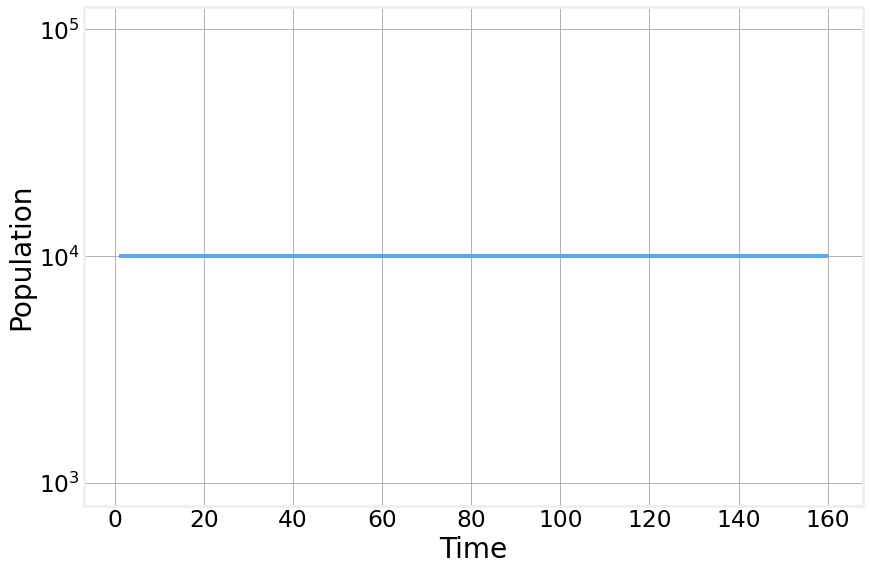

In [15]:
fig, ax = plt.subplots(1)
ax.set_yscale('log')
simple.S.plot(ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Population')


In [16]:
simple.params['death'] = 0.2 # change the death rate to 0.2

In [17]:
simple.integrate(tmax, S=N)

Text(0, 0.5, 'Population')

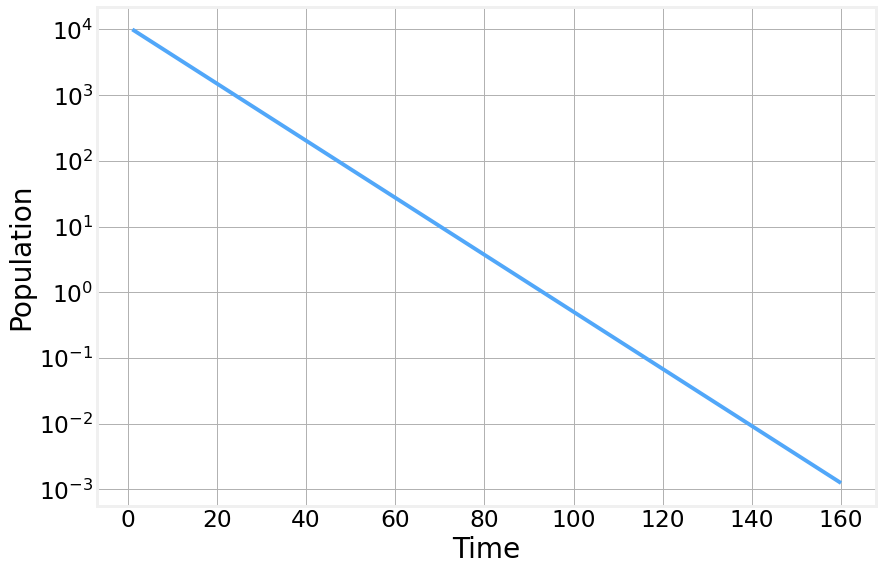

In [18]:
fig, ax = plt.subplots(1)
ax.set_yscale('log')
simple.S.plot(ax=ax)
ax.set_xlabel('Time')
ax.set_ylabel('Population')


Now we build out our full SIR model with demographics. For simplicity, we set the birth and death rates to be the same

In [19]:
gamma = 0.01

SIR_demo = EpiModel()
SIR_demo.add_interaction('S','I', 'I', beta=0.3)
SIR_demo.add_spontaneous('I', 'R', mu=0.1)

SIR_demo.add_birth_rate('S', birth=gamma, global_rate=True)
SIR_demo.add_death_rate(death=gamma)

In [20]:
SIR_demo.integrate(160, S=S0, I=I0, R=R0, tmax=160)


Text(0, 0.5, 'Population')

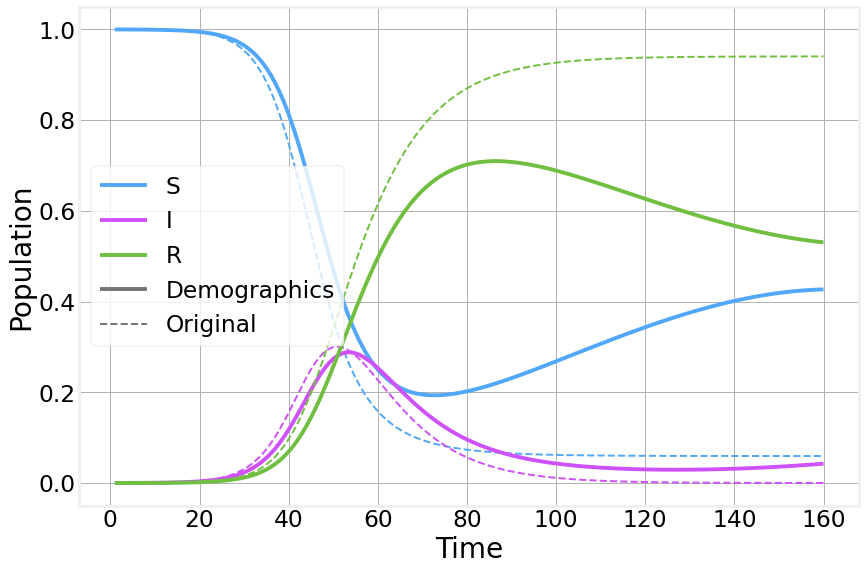

In [21]:
fig, ax = plt.subplots(1)
(SIR_demo.S/N).plot(ax=ax, label='S')
(SIR.S/N).plot(ax=ax, linestyle='--', color=colors[0], lw=2)  # Original SIR for comparison
(SIR_demo.I/N).plot(ax=ax, label='I')
(SIR.I/N).plot(ax=ax, linestyle='--', color=colors[1], lw=2)
(SIR_demo.R/N).plot(ax=ax, label='R')
(SIR.R/N).plot(ax=ax, linestyle='--', color=colors[2], lw=2)


# Create custom line objects for the legend
custom_lines = [Line2D([0], [0], color=colors[0], linestyle='-'),
                Line2D([0], [0], color=colors[1], linestyle='-'),
                Line2D([0], [0], color=colors[2], linestyle='-'),
                Line2D([0], [0], color="#757575", linestyle='-'),
                Line2D([0], [0], color="#757575", lw=2, linestyle='--'),
                ]

# Add the custom lines to the legend
ax.legend(custom_lines, ['S', 'I', 'R', 'Demographics', 'Original'])
ax.set_xlabel('Time')
ax.set_ylabel('Population')

<center>
     <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>